# Train Model V2 - Etape 1: chargement et etude des donnees

Dataset cible: `valakhorasani/gym-members-exercise-dataset`

Objectif de cette etape: charger le dataset puis faire une analyse exploratoire simple (shape, types, valeurs manquantes, stats, distributions).

In [12]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Python cwd :', Path.cwd())

Python cwd : /home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML


## Import de Kagglehub



In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("valakhorasani/gym-members-exercise-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/aldarion/.cache/kagglehub/datasets/valakhorasani/gym-members-exercise-dataset/versions/1


## Telechargement du modele 
Telechargement Kaggle (optionnelle)


In [14]:
# 1) Tentative de telechargement Kaggle (optionnelle)
# Cette cellule peut echouer si internet/API Kaggle indisponible dans le kernel.



dataset_slug = 'valakhorasani/gym-members-exercise-dataset'

from pathlib import Path
download_path = Path("/home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML")



try:
    import kagglehub
    download_path = Path(kagglehub.dataset_download(dataset_slug))
    print('Dataset telecharge dans :', download_path)
except Exception as e:
    print('Telechargement Kaggle ignore ou indisponible :', e)
    print('On passera en fallback sur un fichier local.')

    

Dataset telecharge dans : /home/aldarion/.cache/kagglehub/datasets/valakhorasani/gym-members-exercise-dataset/versions/1


In [15]:
from pathlib import Path
import shutil
import kagglehub

target_dir = Path("/home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML")
target_dir.mkdir(parents=True, exist_ok=True)

cache_path = Path(kagglehub.dataset_download("valakhorasani/gym-members-exercise-dataset"))
shutil.copytree(cache_path, target_dir, dirs_exist_ok=True)

download_path = target_dir
print("Dataset disponible dans :", download_path)


Dataset disponible dans : /home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML


In [16]:
from pathlib import Path
import pandas as pd

base_dir = Path("/home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML")
csv_path = base_dir / "gym_members_exercise_tracking_v2.csv"  # adapte le nom exact

df = pd.read_csv(csv_path)
print("CSV chargé depuis :", csv_path)
df.head()


CSV chargé depuis : /home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML/gym_members_exercise_tracking_v2.csv


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,54,Male,61.0,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,20.86
1,49,Female,63.1,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,26.96
2,30,Female,65.8,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,23.88
3,23,Male,73.5,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,25.43
4,37,Male,73.4,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,22.91


## Etude des données
5) Schema des donnees**. L'idée c'est d'avancer étape par étape, vérifier que ça tourne bien, puis interpréter le résultat avant de passer à la suite.


In [17]:
# 5) Schema des donnees
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

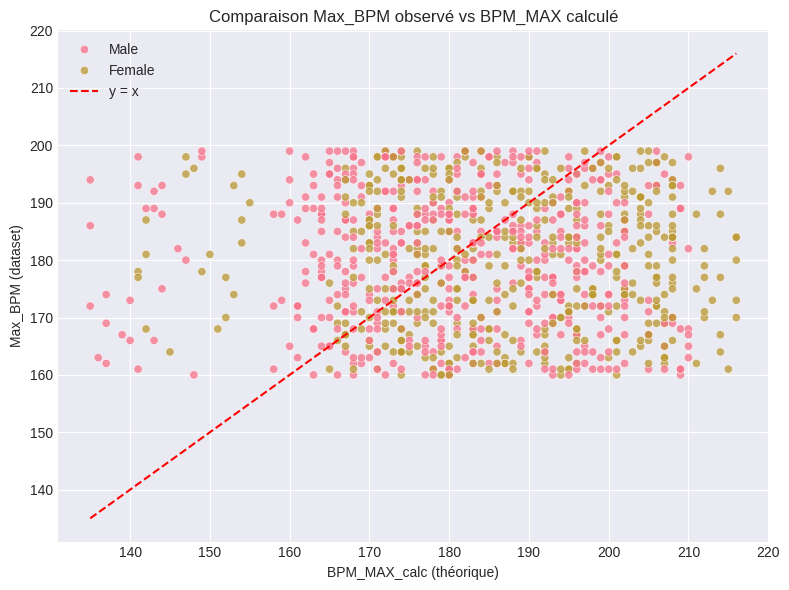

In [18]:
# Nouvelle feature: BPM max théorique selon âge + genre
# Hypothèse utilisée:
# - Homme: 220 - âge
# - Femme: 226 - âge

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Vérif colonnes minimales
required_cols = ["Age", "Gender", "Max_BPM"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes dans df: {missing}")

# Normalisation du genre (robuste à plusieurs écritures)
g = df["Gender"].astype(str).str.strip().str.lower()

is_female = g.isin(["female", "femme", "f", "woman", "feminin", "féminin"])
is_male = g.isin(["male", "homme", "m", "man", "masculin"])

# Feature calculée
df["BPM_MAX_calc"] = np.where(is_female, 226 - df["Age"], 220 - df["Age"])

# (Optionnel) marquer les genres non reconnus qui tombent par défaut sur formule "homme"
unknown_gender = ~(is_female | is_male)
if unknown_gender.any():
    print(f"⚠️ {unknown_gender.sum()} ligne(s) avec genre non reconnu -> formule 220 - âge appliquée.")

# Visualisation: BPM max observé vs BPM max calculé
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="BPM_MAX_calc", y="Max_BPM", hue="Gender", alpha=0.75)

# Ligne de référence y=x
min_v = min(df["BPM_MAX_calc"].min(), df["Max_BPM"].min())
max_v = max(df["BPM_MAX_calc"].max(), df["Max_BPM"].max())
plt.plot([min_v, max_v], [min_v, max_v], "r--", label="y = x")

plt.title("Comparaison Max_BPM observé vs BPM_MAX calculé")
plt.xlabel("BPM_MAX_calc (théorique)")
plt.ylabel("Max_BPM (dataset)")
plt.legend()
plt.tight_layout()
plt.show()


,Age,Gender,Weight (kg),Max_BPM,BPM_MAX_calc
199,39,Male,89.9,170,181
538,45,Male,95.1,176,175
174,46,Male,86.8,194,174
464,73,Male,170.1,180,147
66,32,Male,68.8,176,188
424,43,Female,59.4,165,183
718,11,Male,35.4,189,209
346,54,Male,83.3,194,166
281,10,Female,169.4,170,216
158,18,Male,65.9,173,202


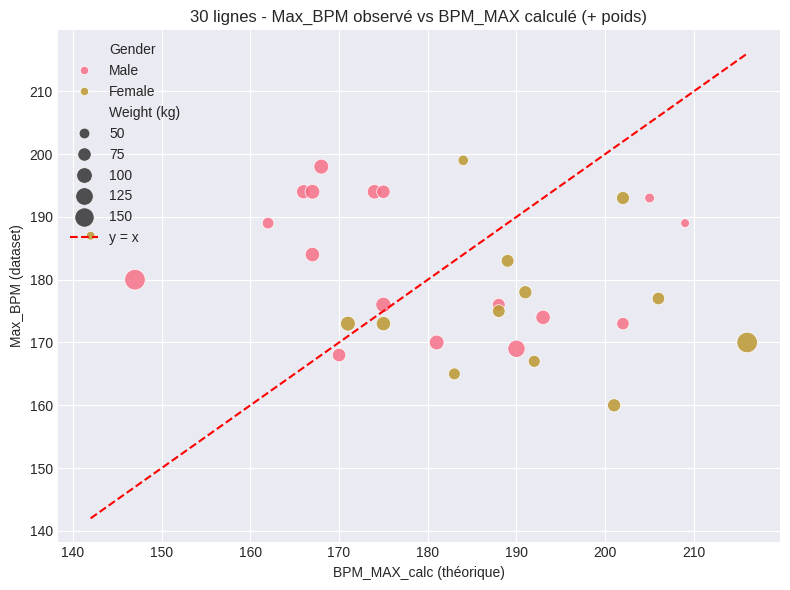

In [19]:
# Visualisation de 30 lignes avec 5 features
# (Age, Gender, Weight (kg), Max_BPM, BPM_MAX_calc)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Échantillon 30 lignes
df_30 = df.sample(n=30, random_state=42).copy()

# 2) Calcul BPM_MAX_calc depuis Age + Gender
g = df_30["Gender"].astype(str).str.strip().str.lower()
is_female = g.isin(["female", "femme", "f", "woman", "feminin", "féminin"])
df_30["BPM_MAX_calc"] = np.where(is_female, 226 - df_30["Age"], 220 - df_30["Age"])

# 3) Garder uniquement les 5 features (avec le poids)
df_30_5f = df_30[["Age", "Gender", "Weight (kg)", "Max_BPM", "BPM_MAX_calc"]].copy()

# 4) Afficher le tableau
display(df_30_5f)

# 5) Graphe comparatif: taille des points = poids
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_30_5f,
    x="BPM_MAX_calc",
    y="Max_BPM",
    hue="Gender",
    size="Weight (kg)",
    sizes=(40, 220),
    alpha=0.85
)

min_v = min(df_30_5f["BPM_MAX_calc"].min(), df_30_5f["Max_BPM"].min())
max_v = max(df_30_5f["BPM_MAX_calc"].max(), df_30_5f["Max_BPM"].max())
plt.plot([min_v, max_v], [min_v, max_v], "r--", label="y = x")

plt.title("30 lignes - Max_BPM observé vs BPM_MAX calculé (+ poids)")
plt.xlabel("BPM_MAX_calc (théorique)")
plt.ylabel("Max_BPM (dataset)")
plt.legend()
plt.tight_layout()
plt.show()


## Création de nouvelles données physiologique plus realiste afin de comparer

Base sur le modèle physiologique de la méthode de Karvonen 

- hr_max_theorique = 220 - age
- hr_ratio = Avg_BPM / hr_max
- Resting_BPM
- hr_reserve = hr_max - Resting_BPM
- hr_ratio_reserve = (Avg_BPM - Resting_BPM) / hr_reserve
- hr_intensity_zone



,Age,Gender,Weight (kg),Avg_BPM,hr_max_theorique,hr_ratio,hr_intensity_zone,Resting_BPM,hr_reserve,hr_ratio_reserve
0,54,Male,61.0,157,166,0.945783,elevee,60,106,0.915094
1,49,Female,63.1,151,171,0.883041,elevee,66,105,0.809524
2,30,Female,65.8,122,190,0.642105,moderee,54,136,0.500000
3,23,Male,73.5,164,197,0.832487,soutenue,56,141,0.765957
4,37,Male,73.4,158,183,0.863388,elevee,68,115,0.782609
5,54,Female,86.6,156,166,0.939759,elevee,74,92,0.891304
6,83,Male,34.7,169,137,1.233577,elevee,73,64,1.500000
7,41,Female,77.0,141,179,0.787709,soutenue,64,115,0.669565
8,29,Male,86.8,127,191,0.664921,moderee,52,139,0.539568
9,27,Male,75.1,136,193,0.704663,moderee,64,129,0.558140


hr_intensity_zone
moderee     337
soutenue    337
elevee      292
faible        7
Name: count, dtype: int64


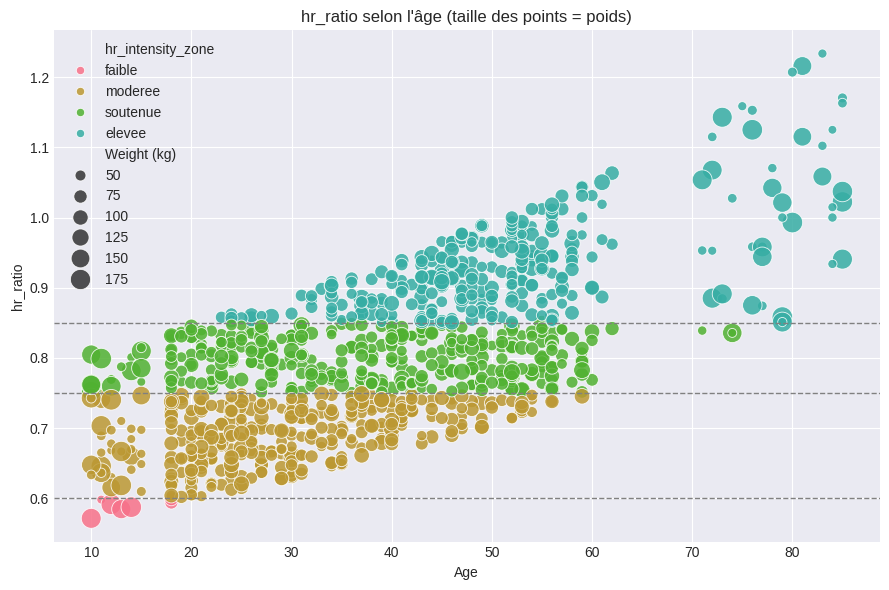

In [20]:
# A) Normalisation cardiaque (version améliorée + poids pour mieux visualiser)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 0) Détection colonne poids
weight_candidates = ["Weight (kg)", "Weight_kg", "Weight", "Poids", "poids"]
weight_col = next((c for c in weight_candidates if c in df.columns), None)

# 1) FC max théorique
df["hr_max_theorique"] = 220 - df["Age"]

# 2) Choix de la FC d'effort
if "Avg_BPM" in df.columns:
    effort_col = "Avg_BPM"
elif "Max_BPM" in df.columns:
    effort_col = "Max_BPM"
else:
    raise ValueError("Il faut au moins une colonne 'Avg_BPM' ou 'Max_BPM' dans df.")

# 3) Ratio cardiaque
df["hr_ratio"] = df[effort_col] / df["hr_max_theorique"]

# 4) Zones d'intensité
bins = [-np.inf, 0.60, 0.75, 0.85, np.inf]
labels = ["faible", "moderee", "soutenue", "elevee"]
df["hr_intensity_zone"] = pd.cut(df["hr_ratio"], bins=bins, labels=labels, right=False)

# 5) HR reserve si FC de repos dispo
rest_candidates = ["Resting_BPM", "Resting_Heart_Rate", "RHR"]
rest_col = next((c for c in rest_candidates if c in df.columns), None)

if rest_col is not None:
    df["hr_reserve"] = df["hr_max_theorique"] - df[rest_col]
    df["hr_ratio_reserve"] = (df[effort_col] - df[rest_col]) / df["hr_reserve"].replace(0, np.nan)

# 6) Aperçu avec poids
cols = ["Age", "Gender"]
if weight_col is not None:
    cols.append(weight_col)
cols += [effort_col, "hr_max_theorique", "hr_ratio", "hr_intensity_zone"]

if rest_col is not None:
    cols += [rest_col, "hr_reserve", "hr_ratio_reserve"]

display(df[cols].head(10))
print(df["hr_intensity_zone"].value_counts(dropna=False))

# 7) Graphique: ratio cardiaque, couleur = zone, taille = poids
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="hr_ratio",
    hue="hr_intensity_zone",
    size=weight_col if weight_col is not None else None,
    sizes=(40, 220),
    alpha=0.85
)
plt.axhline(0.60, ls="--", c="gray", lw=1)
plt.axhline(0.75, ls="--", c="gray", lw=1)
plt.axhline(0.85, ls="--", c="gray", lw=1)
plt.title("hr_ratio selon l'âge (taille des points = poids)")
plt.xlabel("Age")
plt.ylabel("hr_ratio")
plt.tight_layout()
plt.show()


## On note ici une dispertion qui est lié aux données synthétique

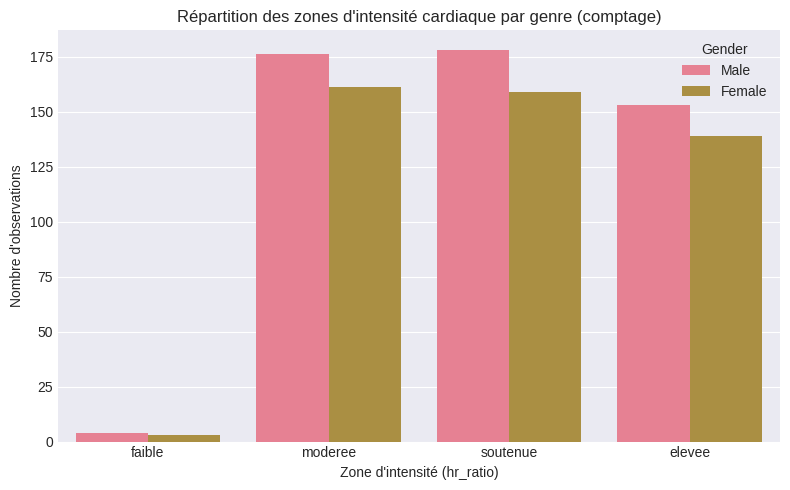

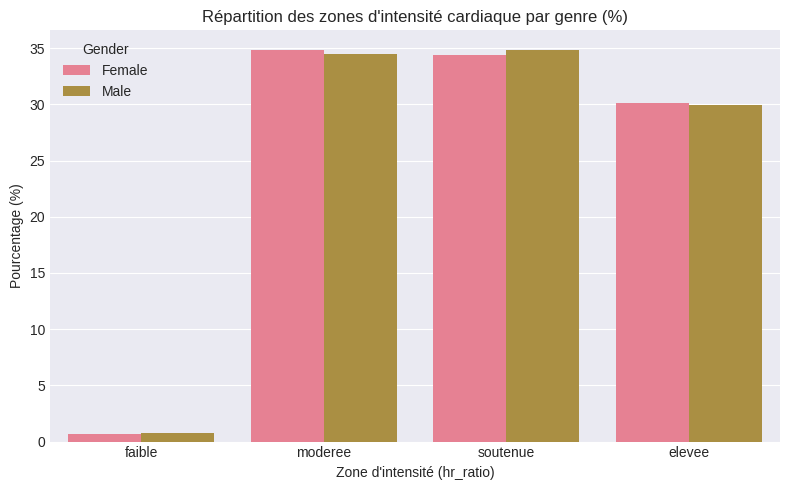

In [21]:
# Visualisation des zones d'intensité cardiaque par genre

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ordre logique des zones
zone_order = ["faible", "moderee", "soutenue", "elevee"]

# Sécuriser le type catégoriel
df["hr_intensity_zone"] = pd.Categorical(df["hr_intensity_zone"], categories=zone_order, ordered=True)

# 1) Comptage brut par genre
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="hr_intensity_zone", hue="Gender", order=zone_order)
plt.title("Répartition des zones d'intensité cardiaque par genre (comptage)")
plt.xlabel("Zone d'intensité (hr_ratio)")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

# 2) Version normalisée (%) par genre
prop = (
    df.groupby(["Gender", "hr_intensity_zone"], observed=False)
      .size()
      .reset_index(name="n")
)
prop["pct"] = prop["n"] / prop.groupby("Gender")["n"].transform("sum") * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=prop, x="hr_intensity_zone", y="pct", hue="Gender", order=zone_order)
plt.title("Répartition des zones d'intensité cardiaque par genre (%)")
plt.xlabel("Zone d'intensité (hr_ratio)")
plt.ylabel("Pourcentage (%)")
plt.tight_layout()
plt.show()


## A partir d'ici j'utilise le nouveau dataset avec les nouvelles features



In [22]:
# Créer un nouveau dataframe de travail (copie)
df_new = df.copy()

# 6) Valeurs manquantes sur le nouveau dataframe
missing = df_new.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_new) * 100).round(2)
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

display(missing_table[missing_table["missing_count"] > 0])

if (missing > 0).sum() == 0:
    print("Aucune valeur manquante detectee.")


,missing_count,missing_pct


Aucune valeur manquante detectee.


> 💬 **Note apprenant**
>
> Ici je lance **7) Statistiques descriptives**. L'idée c'est d'avancer étape par étape, vérifier que ça tourne bien, puis interpréter le résultat avant de passer à la suite.


In [23]:
# 7) Statistiques descriptives
display(df_new.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,973.0,NaN,NaN,NaN,38.810894,15.723865,10.0,26.0,39.0,50.0,85.0
Gender,973,2,Male,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight (kg),973.0,NaN,NaN,NaN,77.704522,27.376472,32.0,61.4,73.1,88.1,182.0
Height (m),973.0,NaN,NaN,NaN,1.72258,0.12772,1.5,1.62,1.71,1.8,2.0
Max_BPM,973.0,NaN,NaN,NaN,179.883864,11.525686,160.0,170.0,180.0,190.0,199.0
Avg_BPM,973.0,NaN,NaN,NaN,143.766701,14.345101,120.0,131.0,143.0,156.0,169.0
Resting_BPM,973.0,NaN,NaN,NaN,62.223022,7.32706,50.0,56.0,62.0,68.0,74.0
Session_Duration (hours),973.0,NaN,NaN,NaN,1.256423,0.343033,0.5,1.04,1.26,1.46,2.0
Calories_Burned,973.0,NaN,NaN,NaN,905.422405,272.641516,303.0,720.0,893.0,1076.0,1783.0
Workout_Type,973,4,Strength,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Visualisation des données numériques et categorielles

In [24]:
# 8) Colonnes numeriques vs categorielles
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print('Colonnes numeriques (', len(num_cols), '):', num_cols)
print('Colonnes categorielles (', len(cat_cols), '):', cat_cols)

Colonnes numeriques ( 18 ): ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'BPM_MAX_calc', 'hr_max_theorique', 'hr_ratio', 'hr_reserve', 'hr_ratio_reserve']
Colonnes categorielles ( 3 ): ['Gender', 'Workout_Type', 'hr_intensity_zone']


## Infos de distribution des données

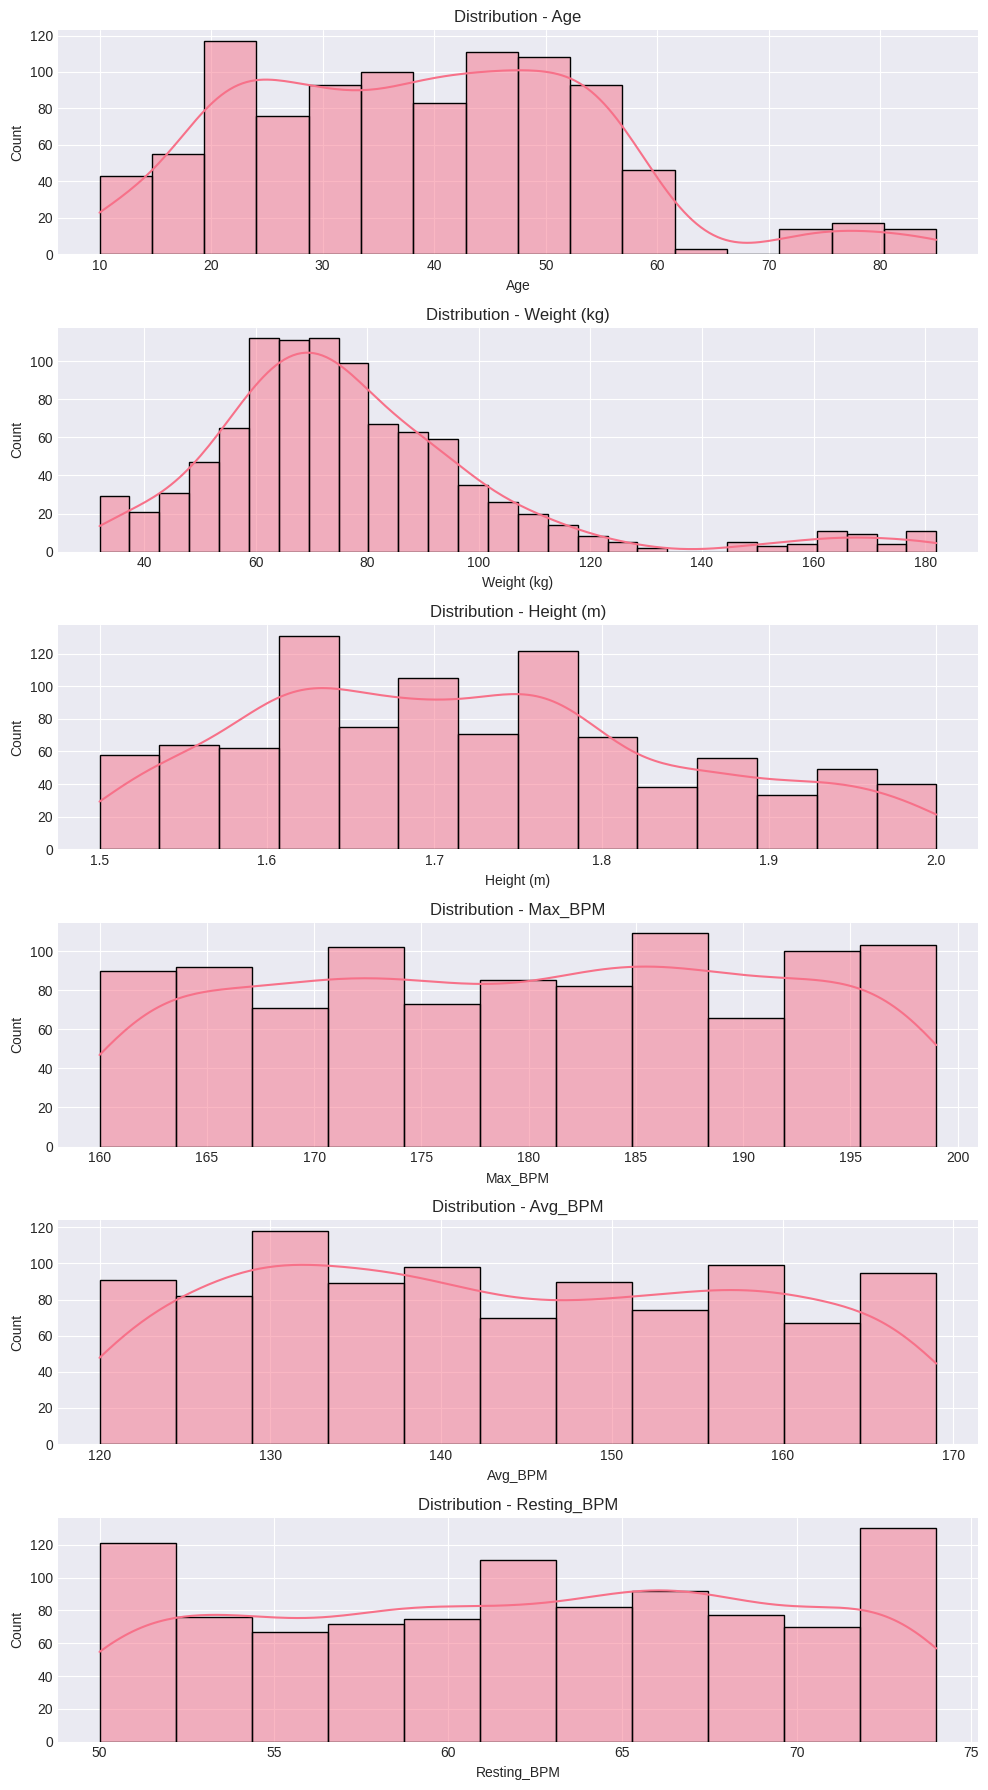

In [25]:
# 9) Distributions de base (top 6 variables numeriques)
cols_to_plot = num_cols[:6]
if cols_to_plot:
    fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 3 * len(cols_to_plot)))
    if len(cols_to_plot) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_to_plot):
        sns.histplot(df[col], kde=True, ax=ax)
        ax.set_title(f'Distribution - {col}')
    plt.tight_layout()
    plt.show()
else:
    print('Aucune colonne numerique a tracer.')

## Fin etape 1

Si tout est OK, prochaine etape: nettoyage + definition des cibles + split train/test pour `train_model_V2`.

> Dans cette cellule, je prépare les données pour l’entraînement du modèle.
>  
> 1. Je crée d’abord la **cible `intensite`** (faible / moyen / eleve) à partir de `Calories_Burned`, en découpant en 3 groupes avec les quantiles (33% et 66%).
> 2. Je construis ensuite la feature cardio la plus utile: **`hr_ratio_reserve`**, qui normalise l’effort selon le profil de la personne :
>    \[
>    (Avg\_BPM - Resting\_BPM) / (hr\_max\_theorique - Resting\_BPM)
>    \]
> 3. Je garde seulement les **variables pertinentes** pour éviter la redondance.
> 4. J’encode `Workout_Type` en numérique (one-hot encoding) pour que le modèle puisse l’utiliser.
> 5. Je nettoie les valeurs invalides (NaN/inf) avant l’étape de split et d’entraînement.
>
> Objectif: obtenir un `model_df` propre, cohérent et directement prêt pour le machine learning.

> Pour entraîner le modèle correctement, j’ai retiré les variables qui créent de la fuite de cible, de la redondance ou une perte d’information :
>
> - `Calories_Burned` : retirée des inputs car elle sert à construire la cible `intensite` (sinon fuite de cible).
> - `hr_ratio` : non retenue car redondante et moins pertinente que `hr_ratio_reserve`.
> - `hr_max_theorique` : variable intermédiaire déjà représentée via `Age` et `hr_ratio_reserve`.
> - `hr_reserve` : variable intermédiaire absorbée par `hr_ratio_reserve`.
> - `hr_intensity_zone` : version discrète (catégories) qui fait perdre de l’information par rapport au ratio continu.
> - `intensite` : retirée de `X` car c’est la variable cible `y`.
>
> Variables finales gardées pour le modèle :
> `Age`, `Weight`, `Avg_BPM`, `Resting_BPM`, `Session_Duration (hours)`, `Workout_Type` (encodé), `hr_ratio_reserve`.



In [26]:
# 1) Créer la cible 3 classes + préparer les features finales (sans redondance)

import numpy as np
import pandas as pd

# --- CIBLE ---
q1, q2 = df["Calories_Burned"].quantile([0.33, 0.66])

def to_intensity(x):
    if x <= q1:
        return "faible"
    elif x <= q2:
        return "moyen"
    else:
        return "eleve"

df["intensite"] = df["Calories_Burned"].apply(to_intensity)
print("Répartition cible :")
print(df["intensite"].value_counts())

# --- FEATURE CLÉ ---
df["hr_max_theorique"] = 220 - df["Age"]
denom = (df["hr_max_theorique"] - df["Resting_BPM"]).replace(0, np.nan)
df["hr_ratio_reserve"] = (df["Avg_BPM"] - df["Resting_BPM"]) / denom

# --- INPUTS À UTILISER ---
# Remarque: adapter "Weight (kg)" si ta colonne s'appelle "Weight"
weight_col = "Weight (kg)" if "Weight (kg)" in df.columns else "Weight"

features = [
    "Age",
    weight_col,
    "Avg_BPM",
    "Resting_BPM",
    "Session_Duration (hours)",  # = Workout_Duration
    "Workout_Type",
    "hr_ratio_reserve",
]

# On garde uniquement les colonnes utiles
model_df = df[features + ["intensite"]].copy()

# Encodage de Workout_Type
model_df = pd.get_dummies(model_df, columns=["Workout_Type"], drop_first=True)

# Nettoyage des éventuelles valeurs inf/NaN créées par le ratio
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

print("\nShape final model_df:", model_df.shape)
display(model_df.head())


Répartition cible :
intensite
eleve     331
moyen     321
faible    321
Name: count, dtype: int64

Shape final model_df: (973, 10)


,Age,Weight (kg),Avg_BPM,Resting_BPM,Session_Duration (hours),hr_ratio_reserve,intensite,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,54,61.0,157,60,1.69,0.915094,eleve,False,False,True
1,49,63.1,151,66,1.30,0.809524,moyen,True,False,False
2,30,65.8,122,54,1.11,0.500000,faible,False,False,False
3,23,73.5,164,56,0.59,0.765957,faible,False,True,False
4,37,73.4,158,68,0.64,0.782609,faible,False,True,False



## Définition X et y (on retire intensité pour éviter fuite de cible)

In [27]:
# 2) Définir X et y à partir du dataframe final (sans fuite de cible)

y = model_df["intensite"]
X = model_df.drop(columns=["intensite"])

print("Shape X:", X.shape)
print("Shape y:", y.shape)
display(X.head())


Shape X: (973, 9)
Shape y: (973,)


,Age,Weight (kg),Avg_BPM,Resting_BPM,Session_Duration (hours),hr_ratio_reserve,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,54,61.0,157,60,1.69,0.915094,False,False,True
1,49,63.1,151,66,1.30,0.809524,True,False,False
2,30,65.8,122,54,1.11,0.500000,False,False,False
3,23,73.5,164,56,0.59,0.765957,False,True,False
4,37,73.4,158,68,0.64,0.782609,False,True,False


## Split train/test


In [28]:
# 3) Split train/test stratifié
from sklearn.model_selection import train_test_split

# Vérif rapide avant split
assert X.index.equals(y.index), "X et y doivent avoir le même index"
print("Taille dataset:", len(X))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("\ny_train distribution (%):\n", (y_train.value_counts(normalize=True) * 100).round(2))
print("\ny_test distribution (%):\n", (y_test.value_counts(normalize=True) * 100).round(2))


Taille dataset: 973
X_train: (778, 9) X_test: (195, 9)

y_train distribution (%):
 intensite
eleve     33.93
faible    33.03
moyen     33.03
Name: proportion, dtype: float64

y_test distribution (%):
 intensite
eleve     34.36
faible    32.82
moyen     32.82
Name: proportion, dtype: float64


## Encodage des variables catégorielles déjà faites auparavant


## Affichage de la Heatmap pour visualiser la correlation entre les features

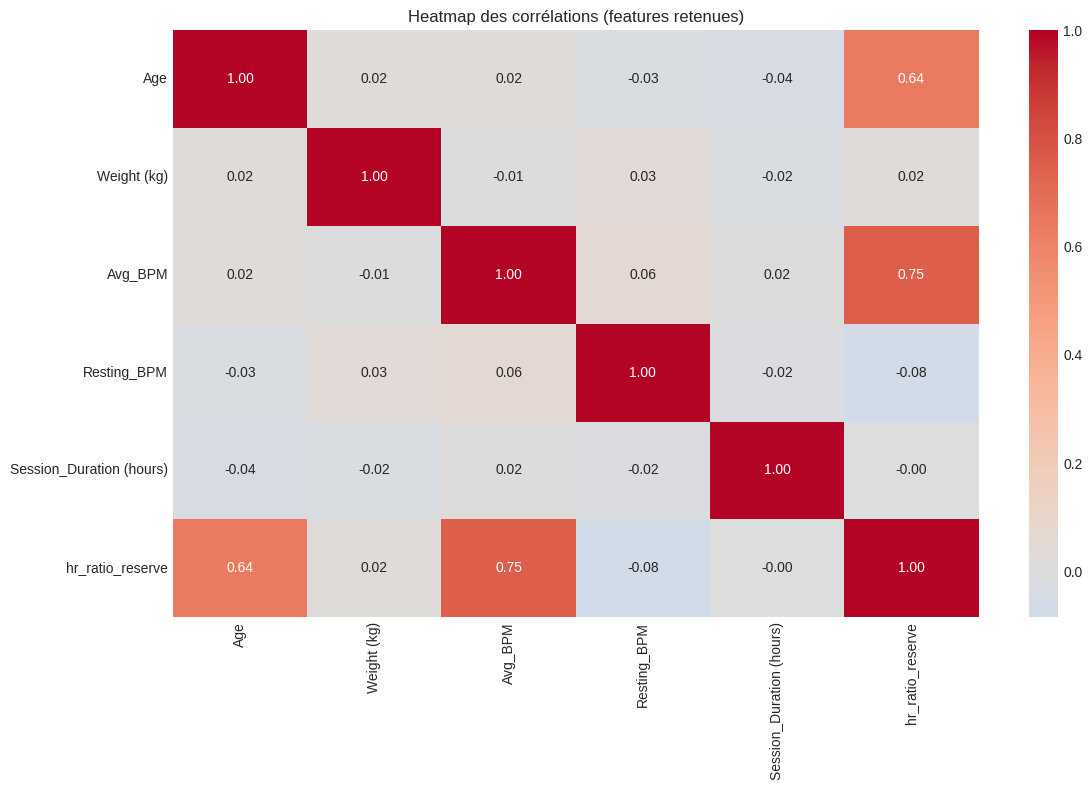

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap sur le dataset de modélisation
# (on exclut la cible textuelle "intensite")
num_df = model_df.select_dtypes(include=["number"])

corr = num_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap des corrélations (features retenues)")
plt.tight_layout()
plt.show()


> 💬 **Note apprenant**
>
> Ici je lance **plt.figure(figsize=(6, 8))**. L'idée c'est d'avancer étape par étape, vérifier que ça tourne bien, puis interpréter le résultat avant de passer à la suite.


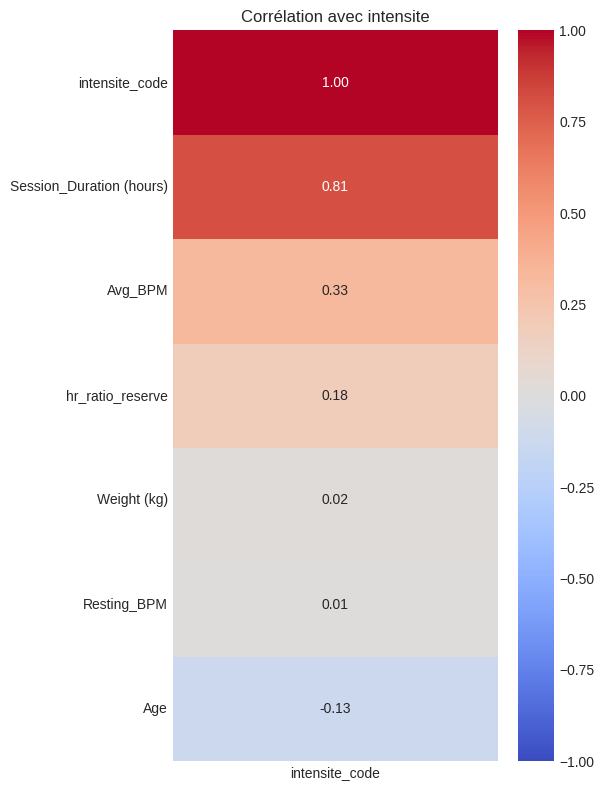

In [30]:
# Corrélation avec la cible intensite (et non Calories_Burned)

import matplotlib.pyplot as plt
import seaborn as sns

tmp = model_df.copy()
tmp["intensite_code"] = tmp["intensite"].map({"faible": 0, "moyen": 1, "eleve": 2})

corr = tmp.select_dtypes(include=["number"]).corr(numeric_only=True)
corr_target = corr[["intensite_code"]].sort_values("intensite_code", ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_target, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Corrélation avec intensite")
plt.tight_layout()
plt.show()


> 💬 **Note apprenant**
>
> Ici je lance **Random Forest - baseline classification intensité (faible/moyen/eleve)**. L'idée c'est d'avancer étape par étape, vérifier que ça tourne bien, puis interpréter le résultat avant de passer à la suite.


Accuracy: 0.8923
F1 macro: 0.8927

Classification report:

              precision    recall  f1-score   support

       eleve     0.9104    0.9104    0.9104        67
      faible     0.9508    0.9062    0.9280        64
       moyen     0.8209    0.8594    0.8397        64

    accuracy                         0.8923       195
   macro avg     0.8941    0.8920    0.8927       195
weighted avg     0.8943    0.8923    0.8930       195



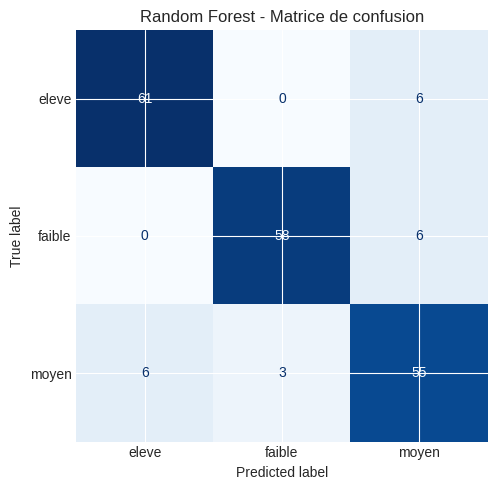

In [31]:
# Random Forest - baseline classification intensité (faible/moyen/eleve)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt

# 1) Modèle
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# 2) Entraînement
rf.fit(X_train, y_train)

# 3) Prédictions
y_pred = rf.predict(X_test)

# 4) Métriques
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"F1 macro: {f1m:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

# 5) Matrice de confusion (ordre dynamique sûr)
labels = sorted(y.unique())   # évite erreur si une classe manque dans y_test
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Random Forest - Matrice de confusion")
plt.tight_layout()
plt.show()


Lecture globale
Ton modèle est bon: Accuracy = 88.21% et F1 macro = 88.38%.
Ça veut dire qu’en moyenne, il classe correctement les 3 niveaux d’intensité.

Rappel rapide des métriques

precision = quand le modèle prédit une classe, à quel point il a raison.
recall = sur tous les vrais exemples d’une classe, combien il retrouve.
f1-score = compromis precision/recall.
Interprétation par classe

faible
Très bon (F1 = 0.912).
57/64 bien classés.
Erreur principale: 7 faible prédits moyen.
eleve
Très bon aussi (F1 = 0.905).
57/67 bien classés.
Erreur principale: 10 eleve prédits moyen.
moyen
Plus difficile (F1 = 0.835).
Recall très bon (0.9062) => il retrouve bien les vrais moyen.
Precision plus faible (0.7733) => il met souvent moyen à tort (des faible et eleve basculent vers moyen).
Ce que montre la matrice de confusion

Les erreurs sont surtout entre classes voisines (faible ↔ moyen, moyen ↔ eleve).
Presque aucune confusion directe faible ↔ eleve (0 dans les deux sens), ce qui est excellent.
Donc le modèle capte bien l’ordre d’intensité, mais la frontière autour de moyen est floue.
Conclusion “mode cours”

Modèle déjà solide pour une V1.
Le point faible logique est la classe intermédiaire moyen, souvent “zone grise”.
C’est un comportement attendu quand on crée 3 classes à partir de quantiles d’une variable continue.


> 💬 **Note apprenant**
>
> Ici je lance **Interprétation du modèle Random Forest avec les importances de variables**. L'idée c'est d'avancer étape par étape, vérifier que ça tourne bien, puis interpréter le résultat avant de passer à la suite.


,importance
Session_Duration (hours),0.562534
Avg_BPM,0.123978
hr_ratio_reserve,0.089572
Age,0.079311
Weight (kg),0.069093
Resting_BPM,0.049591
Workout_Type_Strength,0.009624
Workout_Type_HIIT,0.008283
Workout_Type_Yoga,0.008013


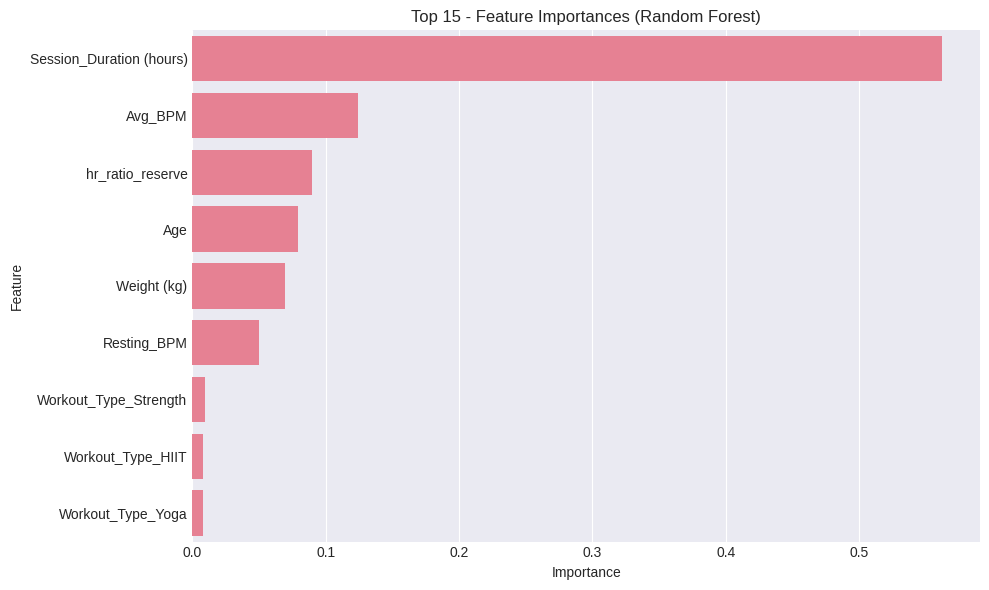

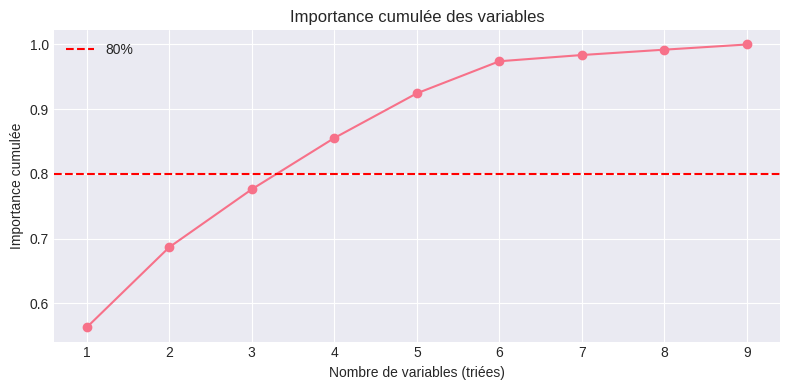

,perm_importance_mean
Session_Duration (hours),0.493846
Avg_BPM,0.198974
Age,0.060000
hr_ratio_reserve,0.027179
Weight (kg),0.006667
Workout_Type_Yoga,0.006154
Workout_Type_Strength,0.000513
Resting_BPM,-0.003077
Workout_Type_HIIT,-0.009231


In [32]:
# Interprétation du modèle Random Forest avec importances

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 0) Sécurité: modèle entraîné
if not hasattr(rf, "feature_importances_"):
    raise ValueError("Le modèle rf doit être entraîné avant cette cellule (rf.fit).")

# 1) Importances natives RF
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

top_n = 15
display(importances.head(top_n).to_frame("importance"))

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, orient="h")
plt.title(f"Top {top_n} - Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 2) Importance cumulée
cum = importances.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum) + 1), cum.values, marker="o")
plt.axhline(0.8, color="red", linestyle="--", label="80%")
plt.title("Importance cumulée des variables")
plt.xlabel("Nombre de variables (triées)")
plt.ylabel("Importance cumulée")
plt.legend()
plt.tight_layout()
plt.show()

# 3) (Recommandé) Permutation importance sur test set
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

display(perm_imp.head(top_n).to_frame("perm_importance_mean"))


## Test avec XGBOOST

> 💬 **Note apprenant**
>
> Ici je lance **1) XGBoost - entraînement + évaluation test**. L'idée c'est d'avancer étape par étape, vérifier que ça tourne bien, puis interpréter le résultat avant de passer à la suite.


XGBoost Accuracy: 0.8923
XGBoost F1 macro: 0.8914

Classification report:

              precision    recall  f1-score   support

       eleve     0.8767    0.9552    0.9143        67
      faible     0.9508    0.9062    0.9280        64
       moyen     0.8525    0.8125    0.8320        64

    accuracy                         0.8923       195
   macro avg     0.8933    0.8913    0.8914       195
weighted avg     0.8931    0.8923    0.8918       195



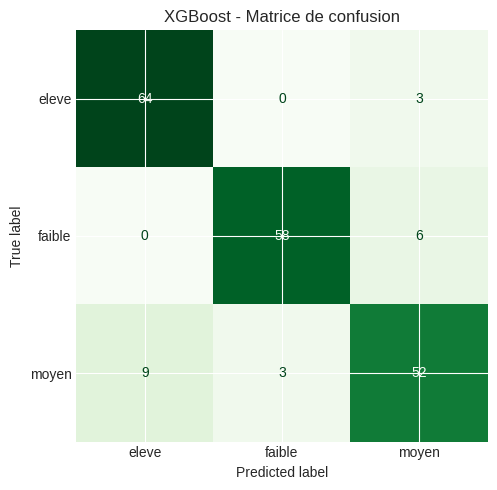

In [33]:
# 1) XGBoost - entraînement + évaluation test
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt

# Encoder y en entiers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

n_classes = len(le.classes_)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=n_classes,      # dynamique
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1                 # plus rapide
)

xgb.fit(X_train, y_train_enc)

y_pred_enc = xgb.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)

acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print(f"XGBoost Accuracy: {acc:.4f}")
print(f"XGBoost F1 macro: {f1m:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

labels = list(le.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Greens", colorbar=False)
plt.title("XGBoost - Matrice de confusion")
plt.tight_layout()
plt.show()


> 💬 **Note apprenant**
>
> Ici je lance **2) Validation croisée (stabilité) pour RF et XGB**. L'idée c'est d'avancer étape par étape, vérifier que ça tourne bien, puis interpréter le résultat avant de passer à la suite.


In [34]:
# 2) Validation croisée (stabilité) pour RF et XGB + sortie en tableau markdown

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Dataset final (déjà préparé, encodé, nettoyé)
X_full = model_df.drop(columns=["intensite"]).copy()
y_full = model_df["intensite"].copy()

# Encodage cible pour XGB
le_cv = LabelEncoder()
y_full_enc = le_cv.fit_transform(y_full)
n_classes = len(le_cv.classes_)

# Validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modèles
rf_cv_model = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

xgb_cv_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=n_classes,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

# Scores CV (F1 macro)
rf_scores = cross_val_score(rf_cv_model, X_full, y_full, cv=cv, scoring="f1_macro")
xgb_scores = cross_val_score(xgb_cv_model, X_full, y_full_enc, cv=cv, scoring="f1_macro")

# Tableau récapitulatif markdown
results_md = pd.DataFrame({
    "Modele": ["RandomForest", "XGBoost"],
    "F1_macro_mean": [rf_scores.mean(), xgb_scores.mean()],
    "F1_macro_std": [rf_scores.std(), xgb_scores.std()],
    "Folds_scores": [
        ", ".join([f"{s:.4f}" for s in rf_scores]),
        ", ".join([f"{s:.4f}" for s in xgb_scores]),
    ],
})

results_md["F1_macro_mean"] = results_md["F1_macro_mean"].round(4)
results_md["F1_macro_std"] = results_md["F1_macro_std"].round(4)

display(results_md)



,Modele,F1_macro_mean,F1_macro_std,Folds_scores
0,RandomForest,0.8654,0.0171,"0.8716, 0.8521, 0.8748, 0.8882, 0.8401"
1,XGBoost,0.8630,0.0235,"0.8407, 0.8725, 0.8594, 0.9030, 0.8394"


> 💬 **Note apprenant**
>
> Ici je lance **3) SHAP (optionnel) - explication du modèle XGBoost**. L'idée c'est d'avancer étape par étape, vérifier que ça tourne bien, puis interpréter le résultat avant de passer à la suite.


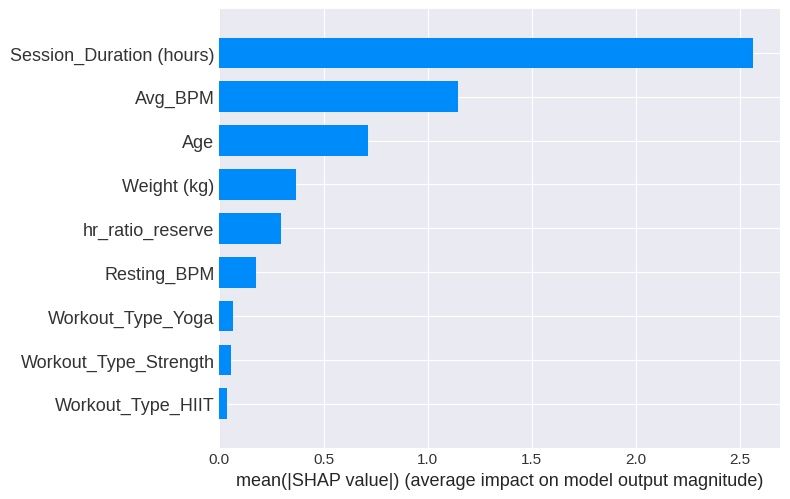

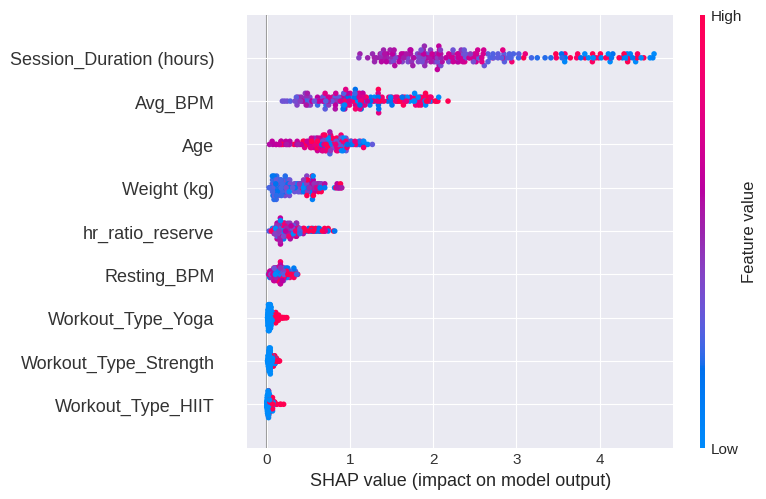

In [35]:
# 3) SHAP (optionnel) - explication du modèle XGBoost (multiclasse)

import shap
import numpy as np

# Explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Selon version SHAP:
# - multiclasse peut renvoyer une liste [classe0, classe1, classe2]
# - ou un array 3D (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    # Agrégation moyenne absolue sur les classes
    shap_abs_mean = np.mean(np.abs(np.stack(shap_values, axis=0)), axis=0)  # (n_samples, n_features)
    shap.summary_plot(shap_abs_mean, X_test, plot_type="bar")
    shap.summary_plot(shap_abs_mean, X_test)
elif getattr(shap_values, "ndim", None) == 3:
    # (n_samples, n_features, n_classes) -> moyenne abs sur classes
    shap_abs_mean = np.mean(np.abs(shap_values), axis=2)
    shap.summary_plot(shap_abs_mean, X_test, plot_type="bar")
    shap.summary_plot(shap_abs_mean, X_test)
else:
    # Binaire / sortie directe
    shap.summary_plot(shap_values, X_test, plot_type="bar")
    shap.summary_plot(shap_values, X_test)


## Regression logistique

> 💬 **Note apprenant**
>
> Ici je lance **Logistic Regression multiclasse (baseline interprétable)**. L'idée c'est d'avancer étape par étape, vérifier que ça tourne bien, puis interpréter le résultat avant de passer à la suite.


LogReg Accuracy: 0.8872
LogReg F1 macro: 0.8887
              precision    recall  f1-score   support

       eleve     0.8906    0.8507    0.8702        67
      faible     0.9836    0.9375    0.9600        64
       moyen     0.8000    0.8750    0.8358        64

    accuracy                         0.8872       195
   macro avg     0.8914    0.8877    0.8887       195
weighted avg     0.8914    0.8872    0.8884       195



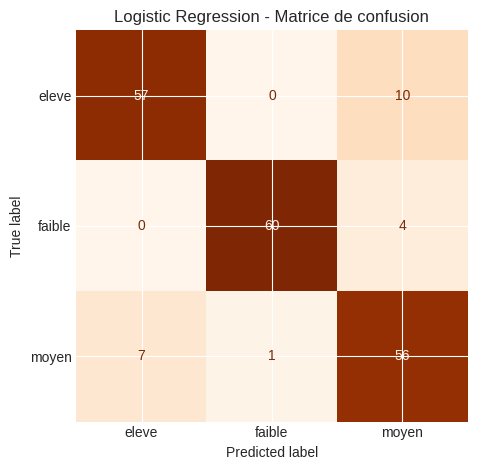

LogReg CV F1 macro: [0.8808 0.8424 0.8673 0.8782 0.8462] | mean = 0.863


In [36]:
# Logistic Regression multiclasse (corrigé bool)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

# 1) Données
X_lr = model_df.drop(columns=["intensite"]).copy()
y_lr = model_df["intensite"].copy()

# IMPORTANT: convertir les bool en int (0/1)
bool_cols = X_lr.select_dtypes(include=["bool"]).columns
X_lr[bool_cols] = X_lr[bool_cols].astype(int)

# 2) Pipeline (tout numérique)
pipe_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="lbfgs", max_iter=3000, class_weight="balanced"))
])

# 3) Split + train/test
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

pipe_lr.fit(X_train_lr, y_train_lr)
y_pred_lr = pipe_lr.predict(X_test_lr)

acc = accuracy_score(y_test_lr, y_pred_lr)
f1m = f1_score(y_test_lr, y_pred_lr, average="macro")

print(f"LogReg Accuracy: {acc:.4f}")
print(f"LogReg F1 macro: {f1m:.4f}")
print(classification_report(y_test_lr, y_pred_lr, digits=4))

labels = sorted(y_lr.unique())
cm = confusion_matrix(y_test_lr, y_pred_lr, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Oranges", colorbar=False)
plt.title("Logistic Regression - Matrice de confusion")
plt.tight_layout()
plt.show()

# 4) CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe_lr, X_lr, y_lr, cv=cv, scoring="f1_macro")
print("LogReg CV F1 macro:", np.round(cv_scores, 4), "| mean =", round(cv_scores.mean(), 4))


,Modele,Accuracy_mean,Precision_macro_mean,Recall_macro_mean,F1_macro_mean,F1_macro_std
2,LogisticRegression,0.9065,0.9093,0.9065,0.9067,0.0085
1,XGBoost,0.8808,0.8830,0.8806,0.8806,0.0252
0,RandomForest,0.8746,0.8795,0.8746,0.8755,0.0232


/tmp/ipykernel_89198/392818202.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Modele", y="F1_macro_mean", palette="Set2")


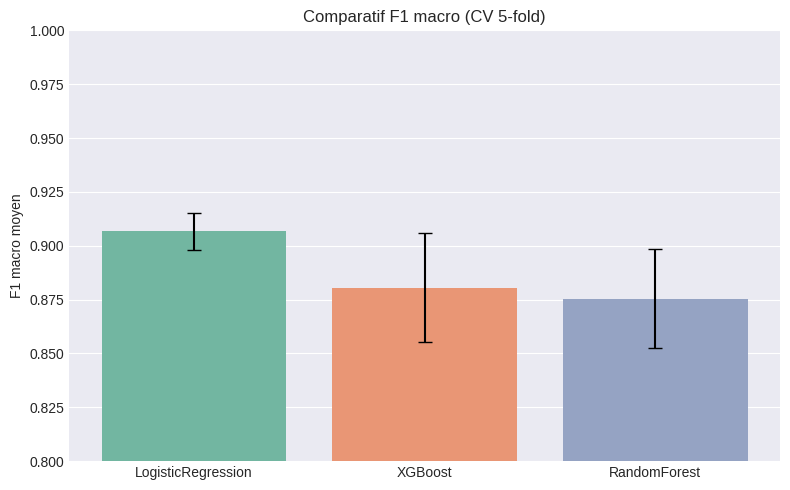

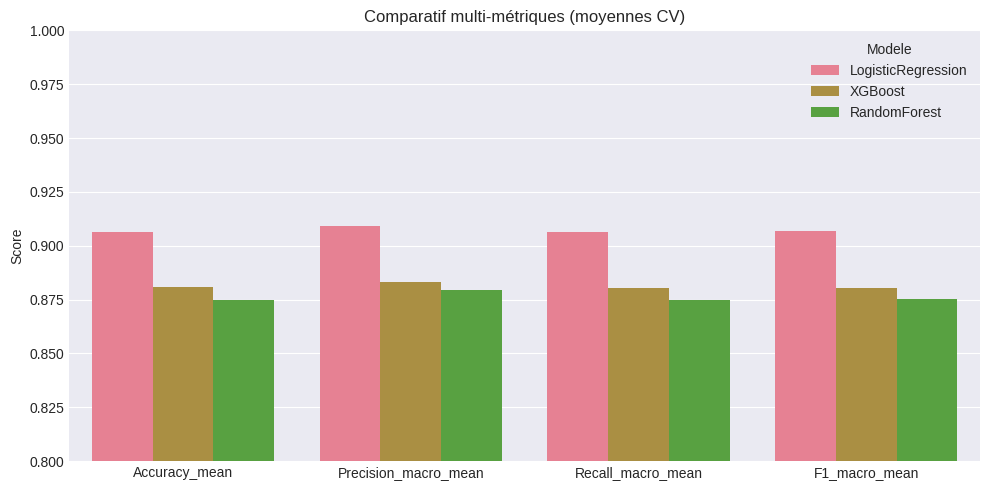

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# =========================
# 1) Préparation des données
# =========================
X = df.drop(columns=["intensite", "Calories_Burned"]).copy()
y = df["intensite"].copy()

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

# Preprocess pour modèles sklearn "classiques"
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# Pour XGBoost : encodage simple via get_dummies
X_xgb = pd.get_dummies(X, drop_first=True)
le = LabelEncoder()
y_xgb = le.fit_transform(y)

# =========================
# 2) Définition des modèles
# =========================
rf_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400, random_state=42, class_weight="balanced"
    ))
])

lr_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(
        solver="lbfgs", max_iter=3000, class_weight="balanced", random_state=42
    ))
])

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 3) Scores CV
# =========================
rf_f1 = cross_val_score(rf_pipe, X, y, cv=cv, scoring="f1_macro")
rf_acc = cross_val_score(rf_pipe, X, y, cv=cv, scoring="accuracy")
rf_prec = cross_val_score(rf_pipe, X, y, cv=cv, scoring="precision_macro")
rf_rec = cross_val_score(rf_pipe, X, y, cv=cv, scoring="recall_macro")

lr_f1 = cross_val_score(lr_pipe, X, y, cv=cv, scoring="f1_macro")
lr_acc = cross_val_score(lr_pipe, X, y, cv=cv, scoring="accuracy")
lr_prec = cross_val_score(lr_pipe, X, y, cv=cv, scoring="precision_macro")
lr_rec = cross_val_score(lr_pipe, X, y, cv=cv, scoring="recall_macro")

xgb_f1 = cross_val_score(xgb_model, X_xgb, y_xgb, cv=cv, scoring="f1_macro")
xgb_acc = cross_val_score(xgb_model, X_xgb, y_xgb, cv=cv, scoring="accuracy")
xgb_prec = cross_val_score(xgb_model, X_xgb, y_xgb, cv=cv, scoring="precision_macro")
xgb_rec = cross_val_score(xgb_model, X_xgb, y_xgb, cv=cv, scoring="recall_macro")

# =========================
# 4) Tableau récapitulatif
# =========================
results = pd.DataFrame({
    "Modele": ["RandomForest", "XGBoost", "LogisticRegression"],
    "Accuracy_mean": [rf_acc.mean(), xgb_acc.mean(), lr_acc.mean()],
    "Precision_macro_mean": [rf_prec.mean(), xgb_prec.mean(), lr_prec.mean()],
    "Recall_macro_mean": [rf_rec.mean(), xgb_rec.mean(), lr_rec.mean()],
    "F1_macro_mean": [rf_f1.mean(), xgb_f1.mean(), lr_f1.mean()],
    "F1_macro_std": [rf_f1.std(), xgb_f1.std(), lr_f1.std()]
}).sort_values("F1_macro_mean", ascending=False)

num_cols = results.select_dtypes(include="number").columns
display(results.style.format({c: "{:.4f}" for c in num_cols}))


# =========================
# 5) Graphique 1 : F1 macro (mean ± std)
# =========================
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Modele", y="F1_macro_mean", palette="Set2")
for i, row in results.reset_index(drop=True).iterrows():
    plt.errorbar(i, row["F1_macro_mean"], yerr=row["F1_macro_std"], fmt='none', c='black', capsize=5)
plt.ylim(0.80, 1.00)
plt.title("Comparatif F1 macro (CV 5-fold)")
plt.ylabel("F1 macro moyen")
plt.xlabel("")
plt.tight_layout()
plt.show()

# =========================
# 6) Graphique 2 : radar-like bar group des métriques
# =========================
plot_df = results.melt(
    id_vars="Modele",
    value_vars=["Accuracy_mean", "Precision_macro_mean", "Recall_macro_mean", "F1_macro_mean"],
    var_name="Metrique",
    value_name="Score"
)

plt.figure(figsize=(10,5))
sns.barplot(data=plot_df, x="Metrique", y="Score", hue="Modele")
plt.ylim(0.80, 1.00)
plt.title("Comparatif multi-métriques (moyennes CV)")
plt.ylabel("Score")
plt.xlabel("")
plt.tight_layout()
plt.show()
